In [1]:
from __future__ import annotations
from argparse import ArgumentParser
from dataclasses import dataclass
from functools import cached_property
import math
from random import randint, random, seed
from typing import Iterator, NamedTuple
import svg

In [2]:
class Point(NamedTuple):
    x: float
    y: float

    def distance_to(self, p: Point) -> float:
        dx = abs(self.x - p.x)
        dy = abs(self.y - p.y)
        return math.sqrt(dx ** 2 + dy ** 2)


class Circle(NamedTuple):
    c: Point
    r: float

    def render(self, stroke: str = "none", fill: str = "none") -> svg.Element:
        return svg.Circle(
            cx=self.c.x, cy=self.c.y, r=self.r,
            stroke=stroke, stroke_width=1,
            fill=fill,
        )

    def contains(self, point: Point) -> bool:
        """Check if the given point is inside the circle
        """
        return self.c.distance_to(point) <= self.r

    def min_distance(self, other: Point) -> float:
        """Shortest distance from circle side to the point
        """
        return abs(self.r - self.c.distance_to(other))

In [3]:
@dataclass
class Generator:
    size: int
    min_shift: int
    max_shift: int
    min_width: int
    min_circles: int
    max_circles: int
    min_radius: int

    def generate(self) -> svg.SVG:
        return svg.SVG(
            width=self.size,
            height=self.size,
            xmlns='http://www.w3.org/2000/svg',
            elements=list(self.iter_elements()),
        )

    @cached_property
    def color(self) -> str:
        hue = randint(0, 360)
        saturation = randint(75, 100)
        return f'hsl({hue}, {saturation}%, 20%)'

    @cached_property
    def outer(self) -> Circle:
        outer_r = self.size // 2
        outer_center = Point(outer_r, outer_r)
        return Circle(c=outer_center, r=outer_r)

    @cached_property
    def inner(self) -> Circle:
        inner_x = self.outer.r + randint(self.min_shift, self.max_shift)
        inner_y = self.outer.r + randint(self.min_shift, self.max_shift)
        inner_center = Point(inner_x, inner_y)
        r = self.outer.min_distance(inner_center) - self.min_width
        return Circle(c=inner_center, r=r)

    def iter_elements(self) -> Iterator[svg.Element]:
        assert self.inner.r < self.outer.r
        yield self.outer.render(fill="white")

        circles_count = randint(self.min_circles, self.max_circles)
        min_distance = math.ceil(self.inner.min_distance(Point(self.outer.r, self.outer.r)))
        circles = [self.inner]
        for _ in range(circles_count):
            for _ in range(40):
                circle = self.get_random_circle(min_distance, circles)
                if circle is not None:
                    circles.append(circle)
                    yield circle.render(stroke=self.color)
                    break

    def get_random_circle(
        self, min_distance: int, circles: list[Circle],
    ) -> Circle | None:
        # pick random coordinates for the center
        distance = randint(min_distance, math.floor(self.outer.r))
        angle = random() * math.pi * 2
        cx = self.outer.r + math.cos(angle) * distance
        cy = self.outer.r + math.sin(angle) * distance
        assert cx >= 0
        assert cy >= 0
        center = Point(cx, cy)

        # do not draw the circle if the center is inside of another circle
        for other in circles:
            if other.contains(center):
                return None

        # pick radius so the circle touches the closest circle
        r = self.outer.min_distance(center)
        for other in circles:
            r = min(r, other.min_distance(center))

        if r < self.min_radius:
            return None
        return Circle(c=center, r=r)

In [9]:
generator = Generator(
        size=800,
        min_shift=20,
        max_shift=60,
        min_width=20,
        min_circles=2000,
        max_circles=3000,
        min_radius=4,
    )
circle_svg = generator.generate()
print(circle_svg)

<svg xmlns="http://www.w3.org/2000/svg" width="800" height="800"><circle stroke="none" stroke-width="1" cx="400" cy="400" r="400" fill="white"/><circle stroke="hsl(141, 96%, 20%)" stroke-width="1" cx="104.71786049246032" cy="312.4074313206316" r="54.81035586376635" fill="none"/><circle stroke="hsl(141, 96%, 20%)" stroke-width="1" cx="267.8044885184364" cy="104.19542474105003" r="75.33726298238622" fill="none"/><circle stroke="hsl(141, 96%, 20%)" stroke-width="1" cx="461.81385166915163" cy="765.8142257236918" r="4.417286530890578" fill="none"/><circle stroke="hsl(141, 96%, 20%)" stroke-width="1" cx="18.298384048094817" cy="315.2363498915704" r="9.0" fill="none"/><circle stroke="hsl(141, 96%, 20%)" stroke-width="1" cx="439.9115023997397" cy="112.75955720651808" r="23.50419262431069" fill="none"/><circle stroke="hsl(141, 96%, 20%)" stroke-width="1" cx="74.24763689890693" cy="500.82855713563305" r="59.0" fill="none"/><circle stroke="hsl(141, 96%, 20%)" stroke-width="1" cx="690.524872208966

In [5]:
from IPython.display import SVG, display

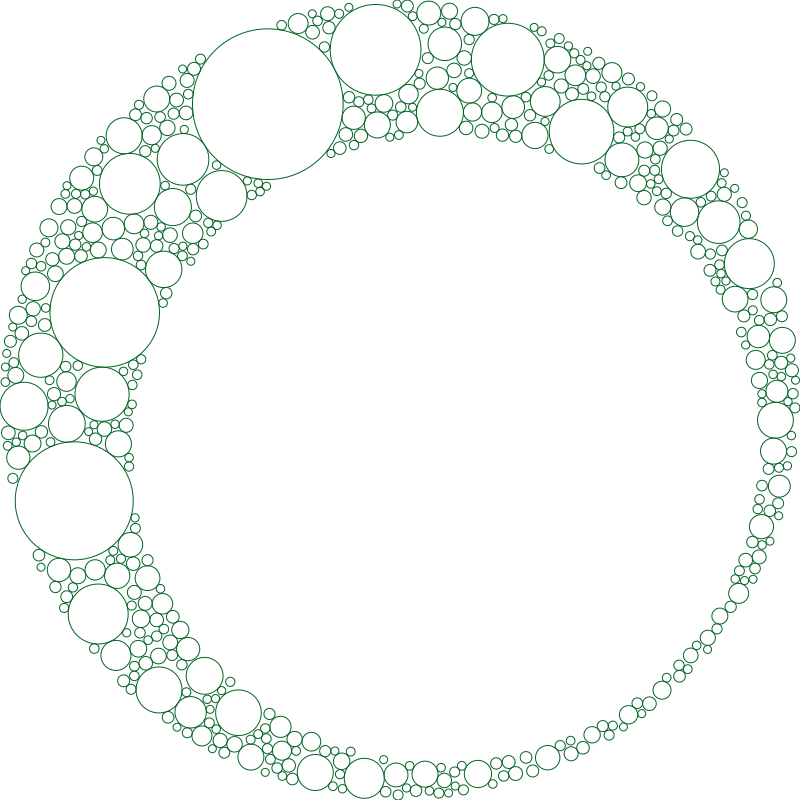

In [12]:
SVG(str(circle_svg))
